In [1]:
# ============================================================
# CÉLULA 1 — Imports e carregamento da base
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configurações de visualização
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

# Caminho da base processada
ROOT = Path().resolve().parent
BASE = ROOT / 'data' / 'processed' / 'base_modelagem.parquet'

# Carrega
df = pd.read_parquet(BASE)

print(f'Shape: {df.shape[0]:,} linhas x {df.shape[1]} colunas')
print(f'\nColunas: {list(df.columns)}')
print(f'\nTipos:')
print(df.dtypes)
print(f'\nPrimeiras 5 linhas:')
df.head()

Shape: 5,342 linhas x 6 colunas

Colunas: ['id_municipio', 'uf', 'taxa_2023', 'taxa_2024', 'atingiu_meta_2025', 'regiao']

Tipos:
id_municipio           int64
uf                       str
taxa_2023            float64
taxa_2024            float64
atingiu_meta_2025      int64
regiao                   str
dtype: object

Primeiras 5 linhas:


,id_municipio,uf,taxa_2023,taxa_2024,atingiu_meta_2025,regiao
0,1100015,RO,64.55,67.79,1,Norte
1,1100023,RO,62.30,65.62,1,Norte
2,1100031,RO,69.10,75.88,1,Norte
3,1100049,RO,63.37,66.07,1,Norte
4,1100056,RO,58.53,66.81,1,Norte


In [3]:
# ============================================================
# CÉLULA 2 — Estatísticas descritivas
# ============================================================
print('ESTATÍSTICAS DESCRITIVAS — variáveis numéricas')
print('='*55)
print(df[['taxa_2023', 'taxa_2024']].describe().round(2))

print('\n\nNULOS POR COLUNA')
print('='*55)
nulos = df.isnull().sum()
perc  = (nulos / len(df) * 100).round(1)
resumo_nulos = pd.DataFrame({'nulos': nulos, 'percentual': perc})
print(resumo_nulos)

print('\n\nDISTRIBUIÇÃO DO ALVO')
print('='*55)
vc = df['atingiu_meta_2025'].value_counts()
for v, c in vc.items():
    label = 'Atingiu meta   (1)' if v == 1 else 'Não atingiu    (0)'
    print(f'  {label}: {c:,} ({c/len(df)*100:.1f}%)')

print('\n\nDISTRIBUIÇÃO POR REGIÃO')
print('='*55)
reg = df.groupby('regiao').agg(
    municipios=('id_municipio', 'count'),
    atingiu=('atingiu_meta_2025', 'sum'),
    taxa_media_2024=('taxa_2024', 'mean')
).round(2)
reg['perc_atingiu'] = (reg['atingiu'] / reg['municipios'] * 100).round(1)
print(reg.sort_values('perc_atingiu', ascending=False).to_string())

ESTATÍSTICAS DESCRITIVAS — variáveis numéricas
       taxa_2023  taxa_2024
count    4765.00    5342.00
mean       60.51      63.33
std        20.02      18.91
min         4.56       4.40
25%        46.09      49.28
50%        61.41      64.38
75%        75.56      77.80
max       100.00     100.00


NULOS POR COLUNA
                   nulos  percentual
id_municipio           0         0.0
uf                     0         0.0
taxa_2023            577        10.8
taxa_2024              0         0.0
atingiu_meta_2025      0         0.0
regiao                 0         0.0


DISTRIBUIÇÃO DO ALVO
  Atingiu meta   (1): 3,888 (72.8%)
  Não atingiu    (0): 1,454 (27.2%)


DISTRIBUIÇÃO POR REGIÃO
              municipios  atingiu  taxa_media_2024  perc_atingiu
regiao                                                          
Centro-Oeste         464      424            72.25          91.4
Nordeste            1753     1382            56.67          78.8
Norte                425      305         

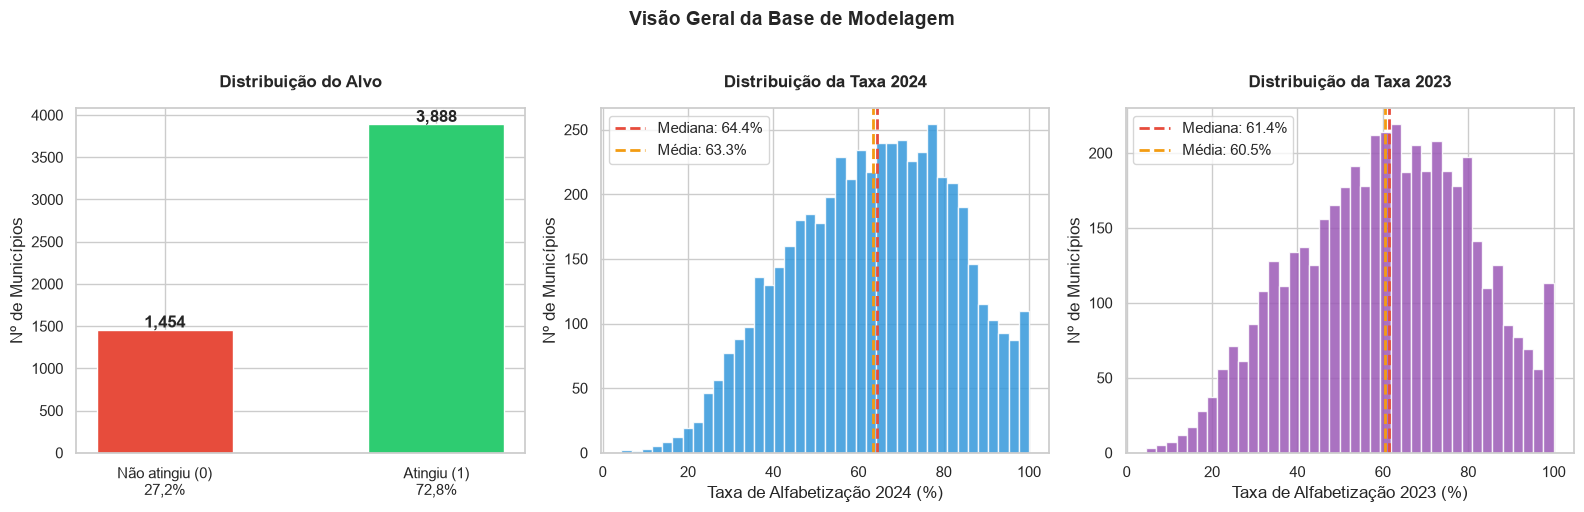

✅ Figura salva em reports/figures/


In [4]:
# ============================================================
# CÉLULA 3 — Distribuição do alvo e features numéricas
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gráfico 1: Distribuição do alvo
cores = ['#e74c3c', '#2ecc71']
labels = ['Não atingiu (0)\n27,2%', 'Atingiu (1)\n72,8%']
valores = df['atingiu_meta_2025'].value_counts().sort_index()
axes[0].bar(labels, valores, color=cores, width=0.5, edgecolor='white')
axes[0].set_title('Distribuição do Alvo', fontweight='bold', pad=15)
axes[0].set_ylabel('Nº de Municípios')
for i, v in enumerate(valores):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontweight='bold')

# Gráfico 2: Distribuição da taxa_2024
axes[1].hist(df['taxa_2024'], bins=40, color='#3498db',
             edgecolor='white', alpha=0.85)
axes[1].axvline(df['taxa_2024'].median(), color='#e74c3c',
                linestyle='--', linewidth=2, label=f'Mediana: {df["taxa_2024"].median():.1f}%')
axes[1].axvline(df['taxa_2024'].mean(), color='#f39c12',
                linestyle='--', linewidth=2, label=f'Média: {df["taxa_2024"].mean():.1f}%')
axes[1].set_title('Distribuição da Taxa 2024', fontweight='bold', pad=15)
axes[1].set_xlabel('Taxa de Alfabetização 2024 (%)')
axes[1].set_ylabel('Nº de Municípios')
axes[1].legend()

# Gráfico 3: Distribuição da taxa_2023
axes[2].hist(df['taxa_2023'].dropna(), bins=40, color='#9b59b6',
             edgecolor='white', alpha=0.85)
axes[2].axvline(df['taxa_2023'].median(), color='#e74c3c',
                linestyle='--', linewidth=2,
                label=f'Mediana: {df["taxa_2023"].median():.1f}%')
axes[2].axvline(df['taxa_2023'].mean(), color='#f39c12',
                linestyle='--', linewidth=2,
                label=f'Média: {df["taxa_2023"].mean():.1f}%')
axes[2].set_title('Distribuição da Taxa 2023', fontweight='bold', pad=15)
axes[2].set_xlabel('Taxa de Alfabetização 2023 (%)')
axes[2].set_ylabel('Nº de Municípios')
axes[2].legend()

plt.suptitle('Visão Geral da Base de Modelagem', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()

# Salva em reports/figures/
fig.savefig(ROOT / 'reports' / 'figures' / '01_distribuicoes_gerais.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figura salva em reports/figures/')

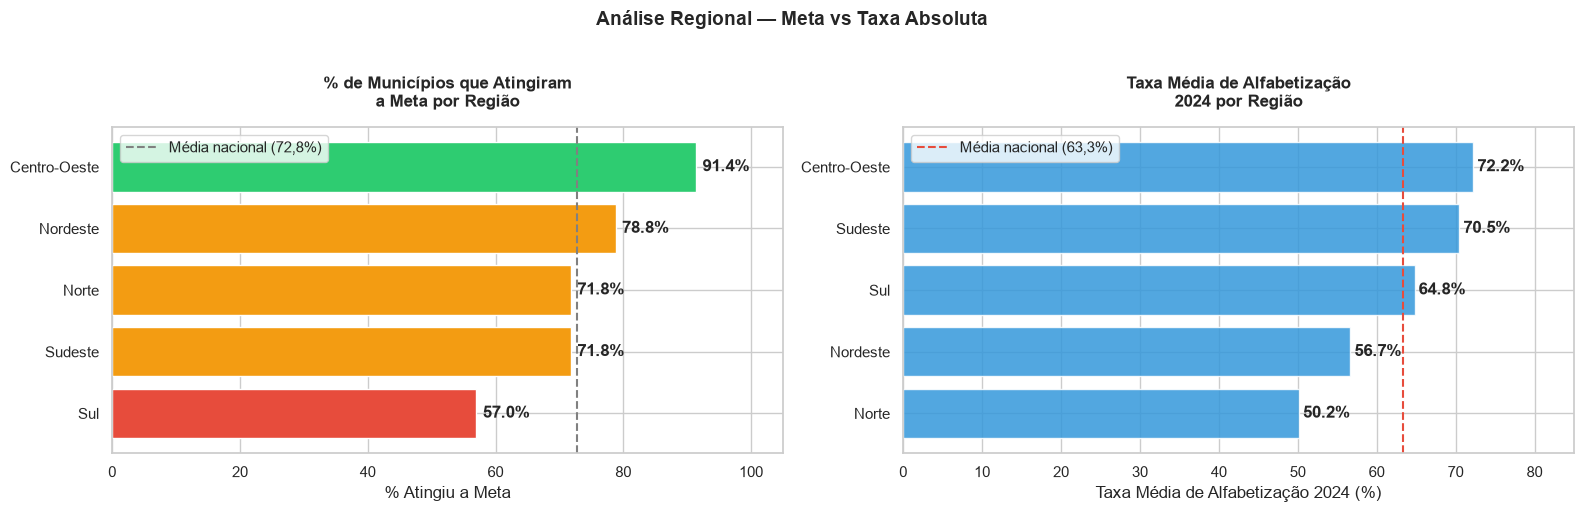

✅ Figura salva em reports/figures/


In [5]:
# ============================================================
# CÉLULA 4 — Atingimento da meta por região
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Dados por região
reg_stats = df.groupby('regiao').agg(
    municipios=('id_municipio', 'count'),
    atingiu=('atingiu_meta_2025', 'sum'),
    taxa_media=('taxa_2024', 'mean')
).reset_index()
reg_stats['perc_atingiu'] = (
    reg_stats['atingiu'] / reg_stats['municipios'] * 100
).round(1)
reg_stats = reg_stats.sort_values('perc_atingiu', ascending=True)

# Gráfico 1: % que atingiu a meta por região
cores_reg = ['#e74c3c' if p < 65 else '#f39c12' if p < 80
             else '#2ecc71' for p in reg_stats['perc_atingiu']]
bars = axes[0].barh(reg_stats['regiao'], reg_stats['perc_atingiu'],
                    color=cores_reg, edgecolor='white')
axes[0].axvline(72.8, color='gray', linestyle='--',
                linewidth=1.5, label='Média nacional (72,8%)')
axes[0].set_title('% de Municípios que Atingiram\na Meta por Região',
                  fontweight='bold', pad=15)
axes[0].set_xlabel('% Atingiu a Meta')
axes[0].set_xlim(0, 105)
axes[0].legend()
for bar, val in zip(bars, reg_stats['perc_atingiu']):
    axes[0].text(val + 1, bar.get_y() + bar.get_height()/2,
                 f'{val}%', va='center', fontweight='bold')

# Gráfico 2: Taxa média de alfabetização 2024 por região
reg_stats2 = reg_stats.sort_values('taxa_media', ascending=True)
bars2 = axes[1].barh(reg_stats2['regiao'], reg_stats2['taxa_media'],
                     color='#3498db', edgecolor='white', alpha=0.85)
axes[1].axvline(63.3, color='#e74c3c', linestyle='--',
                linewidth=1.5, label='Média nacional (63,3%)')
axes[1].set_title('Taxa Média de Alfabetização\n2024 por Região',
                  fontweight='bold', pad=15)
axes[1].set_xlabel('Taxa Média de Alfabetização 2024 (%)')
axes[1].set_xlim(0, 85)
axes[1].legend()
for bar, val in zip(bars2, reg_stats2['taxa_media']):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontweight='bold')

plt.suptitle('Análise Regional — Meta vs Taxa Absoluta',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

fig.savefig(ROOT / 'reports' / 'figures' / '02_analise_regional.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figura salva em reports/figures/')

C:\Users\domain\AppData\Local\Temp\ipykernel_27356\2649494575.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\domain\AppData\Local\Temp\ipykernel_27356\2649494575.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


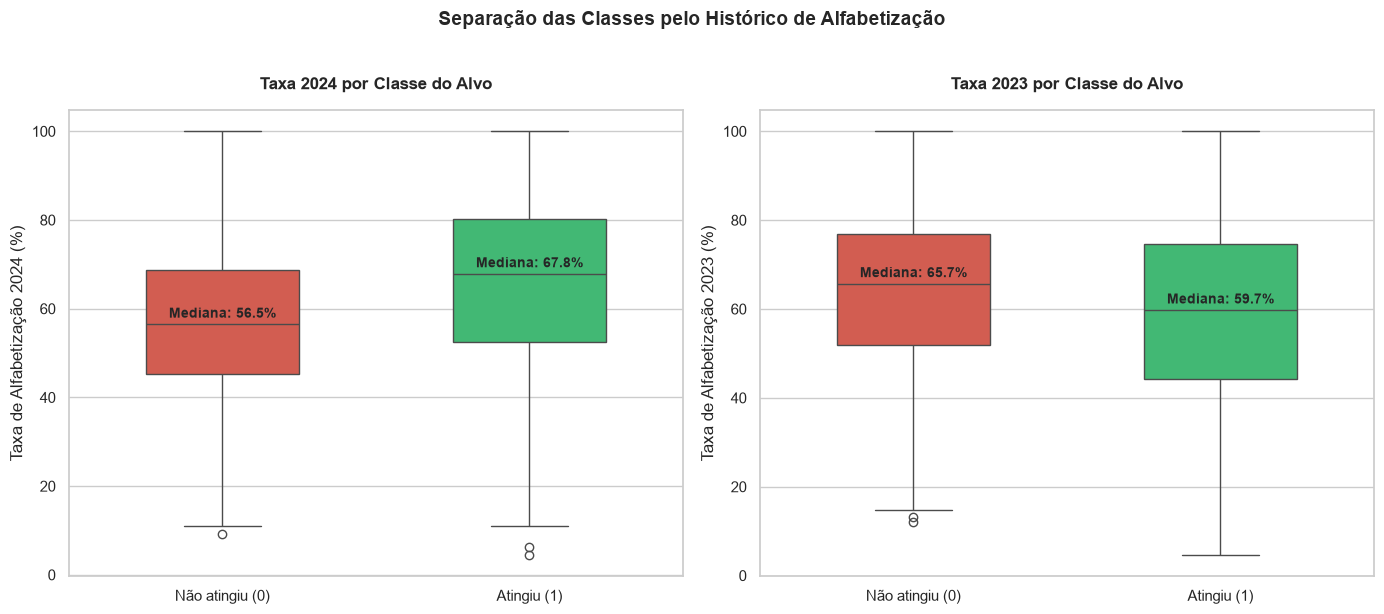

✅ Figura salva em reports/figures/


In [6]:
# ============================================================
# CÉLULA 5 — Distribuição das features por classe do alvo
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

labels_alvo = {0: 'Não atingiu (0)', 1: 'Atingiu (1)'}
df['alvo_label'] = df['atingiu_meta_2025'].map(labels_alvo)

# Boxplot taxa_2024 por classe
sns.boxplot(
    data=df,
    x='alvo_label', y='taxa_2024',
    palette=['#e74c3c', '#2ecc71'],
    order=['Não atingiu (0)', 'Atingiu (1)'],
    ax=axes[0], width=0.5
)
axes[0].set_title('Taxa 2024 por Classe do Alvo',
                  fontweight='bold', pad=15)
axes[0].set_xlabel('')
axes[0].set_ylabel('Taxa de Alfabetização 2024 (%)')

# Mediana de cada grupo
for i, classe in enumerate([0, 1]):
    med = df[df['atingiu_meta_2025']==classe]['taxa_2024'].median()
    axes[0].text(i, med + 1.5, f'Mediana: {med:.1f}%',
                ha='center', fontweight='bold', fontsize=10)

# Boxplot taxa_2023 por classe
sns.boxplot(
    data=df.dropna(subset=['taxa_2023']),
    x='alvo_label', y='taxa_2023',
    palette=['#e74c3c', '#2ecc71'],
    order=['Não atingiu (0)', 'Atingiu (1)'],
    ax=axes[1], width=0.5
)
axes[1].set_title('Taxa 2023 por Classe do Alvo',
                  fontweight='bold', pad=15)
axes[1].set_xlabel('')
axes[1].set_ylabel('Taxa de Alfabetização 2023 (%)')

for i, classe in enumerate([0, 1]):
    sub = df[df['atingiu_meta_2025']==classe].dropna(subset=['taxa_2023'])
    med = sub['taxa_2023'].median()
    axes[1].text(i, med + 1.5, f'Mediana: {med:.1f}%',
                ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Separação das Classes pelo Histórico de Alfabetização',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Remove coluna auxiliar
df.drop(columns=['alvo_label'], inplace=True)

fig.savefig(ROOT / 'reports' / 'figures' / '03_boxplot_por_classe.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figura salva em reports/figures/')

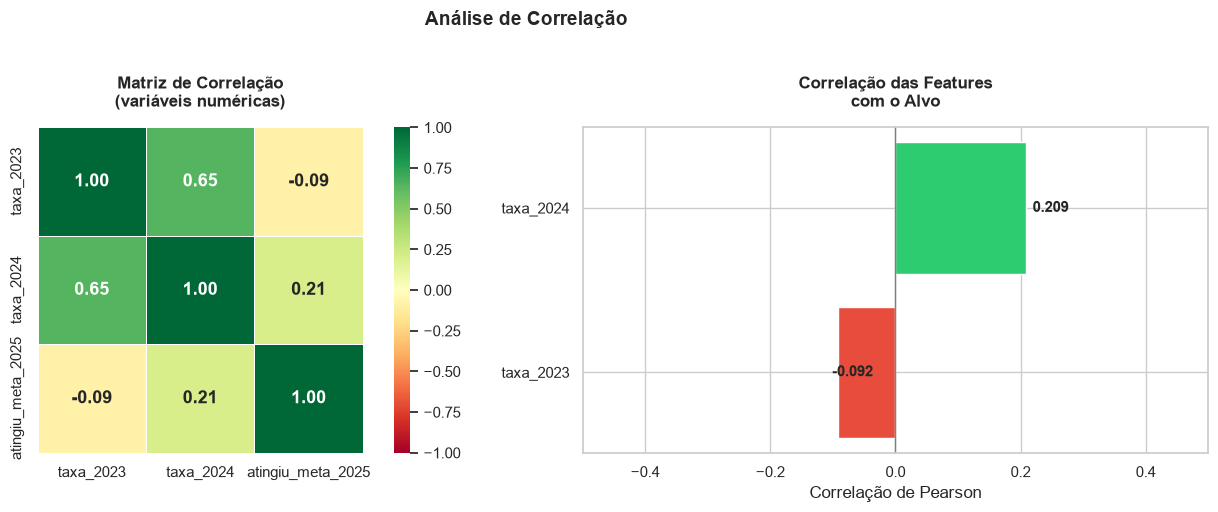

✅ Figura salva em reports/figures/

Correlação com o alvo (atingiu_meta_2025):
taxa_2023   -0.092
taxa_2024    0.209
Name: atingiu_meta_2025, dtype: float64


In [7]:
# ============================================================
# CÉLULA 6 — Matriz de correlação e correlação com o alvo
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de correlação entre variáveis numéricas
numericas = df[['taxa_2023', 'taxa_2024', 'atingiu_meta_2025']]
corr = numericas.corr()

sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    square=True, ax=axes[0],
    linewidths=0.5, annot_kws={'size': 13, 'weight': 'bold'}
)
axes[0].set_title('Matriz de Correlação\n(variáveis numéricas)',
                  fontweight='bold', pad=15)

# Correlação de cada feature com o alvo
corr_alvo = numericas.corr()['atingiu_meta_2025'].drop('atingiu_meta_2025')
cores_corr = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_alvo]
bars = axes[1].barh(corr_alvo.index, corr_alvo.values,
                    color=cores_corr, edgecolor='white')
axes[1].axvline(0, color='gray', linewidth=1)
axes[1].set_title('Correlação das Features\ncom o Alvo',
                  fontweight='bold', pad=15)
axes[1].set_xlabel('Correlação de Pearson')
axes[1].set_xlim(-0.5, 0.5)
for bar, val in zip(bars, corr_alvo.values):
    offset = 0.01 if val >= 0 else -0.01
    ha = 'left' if val >= 0 else 'right'
    axes[1].text(val + offset,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center',
                 fontweight='bold', fontsize=11)

plt.suptitle('Análise de Correlação', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()

fig.savefig(ROOT / 'reports' / 'figures' / '04_correlacoes.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figura salva em reports/figures/')

# Print numérico
print('\nCorrelação com o alvo (atingiu_meta_2025):')
print(corr_alvo.round(3))

In [8]:
# ============================================================
# CÉLULA 7 — Hipóteses analíticas para guiar a modelagem
# ============================================================

hipoteses = """
╔══════════════════════════════════════════════════════════╗
║         HIPÓTESES ANALÍTICAS — Tech Challenge Fase 3     ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  H1: Municípios com maior taxa histórica (2024) têm      ║
║      maior probabilidade de atingir a meta 2025.         ║
║      → Evidência: correlação +0.209 com o alvo           ║
║      → Status: SUPORTADA pelos dados                     ║
║                                                          ║
║  H2: Municípios com taxa alta em 2023 tendem a NÃO       ║
║      atingir a meta — efeito das metas ambiciosas.       ║
║      → Evidência: correlação -0.092 com o alvo           ║
║      → Status: SUPORTADA (padrão contraintuitivo)        ║
║                                                          ║
║  H3: A região geográfica tem poder preditivo             ║
║      independente da taxa histórica.                     ║
║      → Evidência: Centro-Oeste 91.4% vs Sul 57.0%        ║
║      → Status: A CONFIRMAR na modelagem                  ║
║                                                          ║
║  H4: Fatores socioeconômicos (IDH, PIB, FUNDEB)          ║
║      explicam parte da variância não capturada           ║
║      pelas taxas históricas.                             ║
║      → Evidência: correlação máxima atual é 0.209        ║
║        (modelo precisará de mais features)               ║
║      → Status: A CONFIRMAR no enriquecimento externo     ║
║                                                          ║
║  H5: A variação 2023→2024 (tendência) é mais             ║
║      preditiva do que os valores absolutos isolados.     ║
║      → Evidência: sinais opostos de taxa_2023 e          ║
║        taxa_2024 sugerem que a dinâmica importa          ║
║      → Status: A TESTAR na feature engineering           ║
║                                                          ║
╚══════════════════════════════════════════════════════════╝
"""
print(hipoteses)


╔══════════════════════════════════════════════════════════╗
║         HIPÓTESES ANALÍTICAS — Tech Challenge Fase 3     ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  H1: Municípios com maior taxa histórica (2024) têm      ║
║      maior probabilidade de atingir a meta 2025.         ║
║      → Evidência: correlação +0.209 com o alvo           ║
║      → Status: SUPORTADA pelos dados                     ║
║                                                          ║
║  H2: Municípios com taxa alta em 2023 tendem a NÃO       ║
║      atingir a meta — efeito das metas ambiciosas.       ║
║      → Evidência: correlação -0.092 com o alvo           ║
║      → Status: SUPORTADA (padrão contraintuitivo)        ║
║                                                          ║
║  H3: A região geográfica tem poder preditivo             ║
║      independente da taxa histórica.                     ║
║      → Evidência: Cen

In [9]:
# ============================================================
# CÉLULA 8 — Resumo da EDA e próximos passos
# ============================================================

resumo = """
RESUMO DA EDA — Tech Challenge Fase 3
======================================

BASE DE MODELAGEM:
  - 5.342 municípios (rede pública total, ID_TIPO_REDE=5)
  - Alvo: atingiu_meta_2025 → 72,8% sim / 27,2% não
  - Features atuais: taxa_2023, taxa_2024, regiao, uf
  - Nulos: taxa_2023 com 577 (10,8%) → tratar com SimpleImputer

PRINCIPAIS ACHADOS:
  1. taxa_2024 é o preditor mais forte disponível (+0.209 com alvo)
  2. taxa_2023 tem correlação NEGATIVA (-0.092) — efeito das metas
  3. Centro-Oeste: melhor atingimento (91,4%) E taxa alta (72,2%)
  4. Sul: pior atingimento (57,0%) apesar de taxa razoável (64,8%)
  5. Correlações baixas indicam necessidade de enriquecimento externo

HIPÓTESES PARA A MODELAGEM:
  H1: taxa_2024 é preditora positiva ← SUPORTADA
  H2: taxa_2023 alta indica meta difícil ← SUPORTADA
  H3: região tem poder preditivo independente ← A CONFIRMAR
  H4: IDH/PIB/FUNDEB explicam variância residual ← A CONFIRMAR
  H5: variação 2023→2024 é mais preditiva que valores isolados ← A TESTAR

PRÓXIMOS PASSOS:
  → Semana 2: enriquecimento com IBGE, Atlas IDH, FUNDEB
  → Etapa 3: Pipeline Scikit-learn com ColumnTransformer
              (imputação + scaling + encoding + modelo)
  → Feature engineering: criar variacao_2023_2024
"""
print(resumo)


RESUMO DA EDA — Tech Challenge Fase 3

BASE DE MODELAGEM:
  - 5.342 municípios (rede pública total, ID_TIPO_REDE=5)
  - Alvo: atingiu_meta_2025 → 72,8% sim / 27,2% não
  - Features atuais: taxa_2023, taxa_2024, regiao, uf
  - Nulos: taxa_2023 com 577 (10,8%) → tratar com SimpleImputer

PRINCIPAIS ACHADOS:
  1. taxa_2024 é o preditor mais forte disponível (+0.209 com alvo)
  2. taxa_2023 tem correlação NEGATIVA (-0.092) — efeito das metas
  3. Centro-Oeste: melhor atingimento (91,4%) E taxa alta (72,2%)
  4. Sul: pior atingimento (57,0%) apesar de taxa razoável (64,8%)
  5. Correlações baixas indicam necessidade de enriquecimento externo

HIPÓTESES PARA A MODELAGEM:
  H1: taxa_2024 é preditora positiva ← SUPORTADA
  H2: taxa_2023 alta indica meta difícil ← SUPORTADA
  H3: região tem poder preditivo independente ← A CONFIRMAR
  H4: IDH/PIB/FUNDEB explicam variância residual ← A CONFIRMAR
  H5: variação 2023→2024 é mais preditiva que valores isolados ← A TESTAR

PRÓXIMOS PASSOS:
  → Sema